# Second-harmonic generation: red light in, blue light out

Shine a red laser on a crystal and, if the crystal is the right one, some of the light comes
out blue. Two photons of energy $\hbar\omega$ go in and one of energy $2\hbar\omega$ comes
out. It is the effect that turns a 1064 nm infrared laser into the 532 nm green of a laser
pointer, and it is the first thing anyone measures about a nonlinear optical material.

The response is second order in the field,

$$ P^a(2\omega) \;=\; \chi^{abc}(-2\omega;\omega,\omega)\,E_b(\omega)\,E_c(\omega), $$

and $\chi^{abc}$ is a polar rank-3 tensor. That single fact decides which crystals can do it
at all: **a crystal with an inversion centre has none of it**. Silicon, germanium, diamond and
table salt are all silent. AlAs, GaAs, quartz and lithium niobate are not.

This notebook computes the whole complex spectrum for AlAs and checks it against the
all-electron code Elk, which is one of the few programs that computes the same quantity.

In [1]:
from pathlib import Path

import numpy as np

from defumat import Calculator
from defumat.system.kpoints import KPoints

PSEUDO, CASES = Path("../tests/data/pseudo"), Path("../tests/data/qe")

alas = Calculator.from_file(CASES / "alas-shg.in", PSEUDO, announce=False)
mesh = KPoints.automatic((6, 6, 6), (0, 0, 0), alas.system.cell)
chi = alas.get_shg(kpoints=mesh, nbnd=22, window=0.6, nw=240, broadening=0.010)

xyz = chi.component(0, 1, 2)
print("AlAs chi_xyz at low frequency = %.1f pm/V  (d = %.1f pm/V)"
      % (xyz[0].real, xyz[0].real / 2))

AlAs chi_xyz at low frequency = -75.8 pm/V  (d = -37.9 pm/V)


## Zincblende leaves exactly one number

AlAs is $\bar{4}3m$. A rank-3 tensor symmetric in its last two labels has 18 independent
entries in general, and this point group leaves **one**: the components with all three labels
different, which are all equal to each other, and nothing else.

Nothing in the calculation imposes that. The three cartesian directions are treated
identically, the Brillouin-zone sum runs over the whole grid with no symmetry averaging, and
each of the 27 components is assembled separately. So the pattern below is a result, and the
components that vanish do so by cancellation in the zone sum.

In [2]:
labels = "xyz"
peaks = {(a, b, c): np.abs(chi.component(a, b, c)).max()
         for a in range(3) for b in range(3) for c in range(3)}
largest = max(peaks.values())

survive = {k: v for k, v in peaks.items() if v > 1e-2 * largest}
for (a, b, c), value in sorted(survive.items()):
    print("chi^%s%s%s  %8.1f pm/V" % (labels[a], labels[b], labels[c], value))
print("\nlargest of the other %d components: %.2e of the peak"
      % (27 - len(survive), max(v for k, v in peaks.items() if k not in survive) / largest))

chi^xyz     672.4 pm/V
chi^xzy     672.4 pm/V
chi^yxz     672.4 pm/V
chi^yzx     672.4 pm/V
chi^zxy     672.6 pm/V
chi^zyx     672.6 pm/V

largest of the other 21 components: 4.07e-04 of the peak


## The control: silicon has to give nothing

A number that comes out small has to be shown to be small for the right reason. Silicon is
diamond structure, which has an inversion centre, so every component of $\chi^{abc}$ is
forbidden. It differs from AlAs by one species and is otherwise the same calculation, which
makes it the sharpest test of the whole machinery that exists here.

In [3]:
silicon = Calculator.from_file(CASES / "si2-nosym.in", PSEUDO, announce=False)
si_mesh = KPoints.automatic((6, 6, 6), (0, 0, 0), silicon.system.cell)
si_chi = silicon.get_shg(kpoints=si_mesh, nbnd=14, window=0.6, nw=120, broadening=0.010)

print("AlAs    peak |chi| = %9.2f pm/V" % np.abs(chi.chi).max())
print("silicon peak |chi| = %9.4f pm/V" % np.abs(si_chi.chi).max())
print("ratio              = %.1e" % (np.abs(si_chi.chi).max() / np.abs(chi.chi).max()))

AlAs    peak |chi| =    672.58 pm/V
silicon peak |chi| =    0.0120 pm/V
ratio              = 1.8e-05


## The spectrum, and where its absorption starts

The plot below is the one piece of physics worth staring at. A **linear** absorption spectrum
becomes finite when a single photon reaches the gap. This one becomes finite when **two**
photons do, at half the gap, because the outgoing photon is the one that has to land on a real
transition. So the imaginary part switches on an octave below where the crystal starts
absorbing ordinary light, and the strongest features sit between the two.

That is not a detail of the formalism. It is why a transparent crystal can still be a poor
frequency doubler: the material is clear at $\omega$ and opaque at $2\omega$.

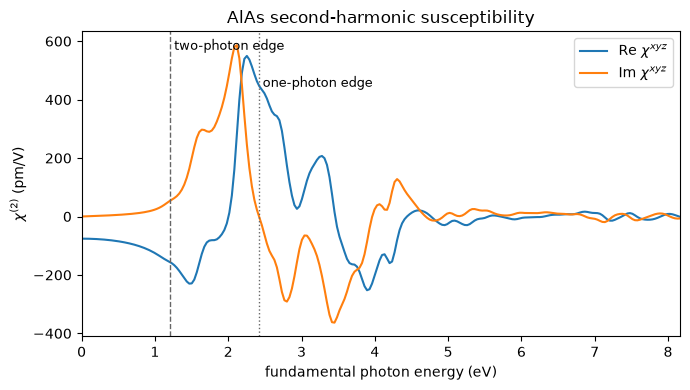

In [4]:
import matplotlib.pyplot as plt

bands = np.asarray(alas.get_scf(nbnd=12).eigenvalues)
direct = float(np.min(bands[:, 4] - bands[:, 3])) * 13.605693
ev = chi.frequencies_ev

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ev, xyz.real, label=r"Re $\chi^{xyz}$")
ax.plot(ev, xyz.imag, label=r"Im $\chi^{xyz}$")
ax.axvline(direct / 2, color="0.4", ls="--", lw=1)
ax.axvline(direct, color="0.4", ls=":", lw=1)
ax.text(direct / 2, ax.get_ylim()[1] * 0.9, " two-photon edge", fontsize=9)
ax.text(direct, ax.get_ylim()[1] * 0.7, " one-photon edge", fontsize=9)
ax.set_xlabel("fundamental photon energy (eV)")
ax.set_ylabel(r"$\chi^{(2)}$ (pm/V)")
ax.set_title("AlAs second-harmonic susceptibility")
ax.legend(); ax.set_xlim(0, ev.max()); fig.tight_layout()

## Against an all-electron code

Elk computes this same tensor, and the crystal here was chosen so the two can be compared
directly. The comparison is not digit-for-digit and should not be read as one: Elk expands the
wavefunctions in atomic spheres plus plane waves where this uses plane waves and a
pseudopotential, and the two do not have exactly the same band gap. Since a second-order
susceptibility carries two energy denominators, a gap difference is not a simple scale factor.

What the two agree on is where the resonance sits and how big the response is.

In [5]:
def elk(name):
    blocks = (Path("../tests/data/elk") / name).read_text().split("\n\n")
    rows = [np.array([[float(x) for x in l.split()] for l in b.strip().splitlines()])
            for b in blocks[:2]]
    return rows[0][:, 0] * 27.211386, rows[0][:, 1] + 1j * rows[1][:, 1]

w_elk, chi_elk = elk("alas-chi2-123.elk.out")
i, j = np.abs(xyz).argmax(), np.abs(chi_elk).argmax()
print("                    defumat     Elk")
print("resonance (eV)      %8.3f  %8.3f" % (ev[i], w_elk[j]))
print("peak |chi| (pm/V)   %8.1f  %8.1f" % (np.abs(xyz[i]), np.abs(chi_elk[j]) * 24.4377))
print("chi(0)     (pm/V)   %8.1f  %8.1f" % (xyz[0].real, chi_elk[0].real * 24.4377))

                    defumat     Elk
resonance (eV)         2.152     2.163
peak |chi| (pm/V)      672.4     628.0
chi(0)     (pm/V)      -75.8     -85.4


## What the number means

AlAs comes out with $d = \chi/2$ of roughly 40 pm/V at low frequency. For comparison,
quartz, the workhorse of early nonlinear optics, has $d_{11} \approx 0.3$ pm/V, lithium
niobate has $d_{33} \approx 27$, and the zincblende semiconductors are the strong end of the
range at tens to a couple of hundred. So AlAs is a good doubler in the same way GaAs is, and
for the same reason: a small gap and a heavily polarizable bond, with no inversion centre to
switch it off.

Two things are worth knowing before quoting any such number. The literature usually reports
$d = \chi/2$ rather than $\chi$ itself, so a factor of two is easy to lose. And the answer
depends on the band gap twice over, which is why calculations of this quantity are often run
with the gap corrected by hand towards the measured one; `scissor` does that here, and it
moves the doubling resonance by half the shift rather than by the whole of it.

In [6]:
print("chi = %.1f pm/V   ->   d = %.1f pm/V" % (xyz[0].real, xyz[0].real / 2))
print("band truncation diagnostic: %.1e of the peak" % chi.truncation)

chi = -75.8 pm/V   ->   d = -37.9 pm/V
band truncation diagnostic: 2.9e-03 of the peak


---

The tensor is assembled from the interband dipole matrix elements of the crystal and their
resonances at $\omega$ and $2\omega$; no expression is differentiated by hand anywhere in it.

The convergence sweeps behind the numbers quoted here, the comparison against Elk's three
separate contributions, and the checks that silicon vanishes and that the absorption edge sits
at half the gap all live in `tests/regression/test_shg.py` and
`tests/unit/test_shg_machinery.py`.